In [1]:
import numpy as np
import getdist.plots
import matplotlib.pyplot as plt
import yaml
import sys
import os
import shutil

# So the Jupyter kernel finds LaTeX when started from Cursor/VS Code
if not shutil.which('pdflatex'):
    os.environ['PATH'] = '/Library/TeX/texbin:' + os.environ.get('PATH', '')

# Load parameter configuration files
# params_names.yaml contains the mapping from parameter names to LaTeX labels
with open("params_names.yaml", "r") as file:
    params_dic = yaml.safe_load(file)

# params_model_shear.yaml contains fiducial values and prior ranges
with open("params_model_spectro.yaml", "r") as file:
    fiducials = yaml.safe_load(file)
print(shutil.which("latex"))

/Library/TeX/texbin/latex


In [2]:
# Set up plotting style and colors
import seaborn as sns
sns.set_theme(style="ticks")
colors = sns.color_palette("Set2")  # Use seaborn Set2 color palette

plt.ioff()  # prevent post-execute redraws that can trigger LaTeX errors in callbacks

# Use matplotlib's built-in text (no LaTeX required)
from matplotlib import rc
rc('text', usetex=False)
rc('font', **{'family': 'serif', 'serif': ['DejaVu Serif']})


In [3]:
chain = np.load('../sampling/chains/wrong_likelihood/chain_spec_pbj_DR1_like_jef.npz', allow_pickle=True)
chain_sigma1 = np.load('../sampling/chains/wrong_likelihood/chain_spec_pbj_DR1_like_jef_b2bG2sigma1.npz', allow_pickle=True)

In [4]:
# =============================================================================
# GETDIST SAMPLE PREPARATION
# =============================================================================
ModelPars =['ombh2', 'omch2', 'logAs', 'ns', 'H0']
samples = []    
samples.append(
    getdist.MCSamples(
        # Sample data (excluding log-likelihood and weight columns)
        samples = chain['chain'][:, :len(ModelPars)],
        # Parameter names
        names = [i for i in ModelPars],
        # Sample weights (exponential of log-likelihood)
        weights=np.exp(chain['weights']),
        # LaTeX labels for parameters (from params_dic)
        labels = [params_dic[p] for p in ModelPars],
        # Smoothing settings for 1D and 2D distributions
        settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35},
        # Parameter ranges for plotting
        #ranges = Ranges
    ) 
)
samples.append(
    getdist.MCSamples(
        # Sample data (excluding log-likelihood and weight columns)
        samples = chain_sigma1['chain'][:, :len(ModelPars)],
        # Parameter names
        names = [i for i in ModelPars],
        # Sample weights (exponential of log-likelihood)
        weights=np.exp(chain_sigma1['weights']),
        # LaTeX labels for parameters (from params_dic)
        labels = [params_dic[p] for p in ModelPars],
        # Smoothing settings for 1D and 2D distributions
        settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35},
        # Parameter ranges for plotting
        #ranges = Ranges
    ) 
)

Removed no burn in
Removed no burn in


<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_3811/3812369750.py:14: SyntaxWarning: invalid escape sequence '\s'
  legend_labels=['Jeffreys, $\sigma_{b_2, b_{G2}}=10$', 'Jeffreys, $\sigma_{b_2, b_{G2}}=1$']
/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_3811/3812369750.py:14: SyntaxWarning: invalid escape sequence '\s'
  legend_labels=['Jeffreys, $\sigma_{b_2, b_{G2}}=10$', 'Jeffreys, $\sigma_{b_2, b_{G2}}=1$']


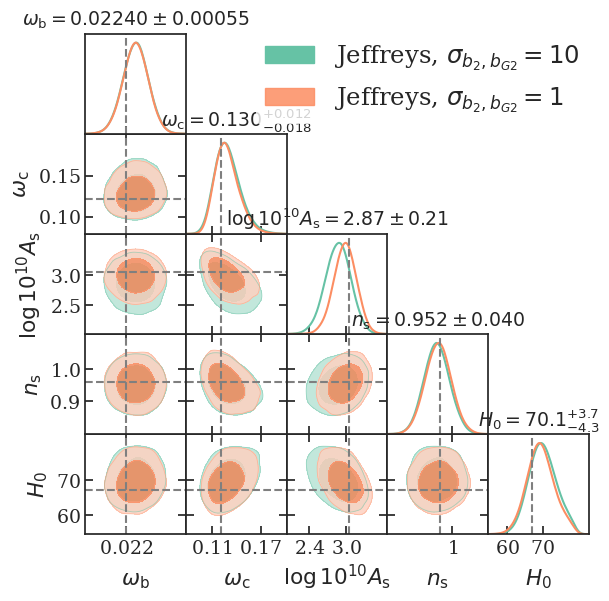

In [5]:

# =============================================================================
# CREATE TRIANGLE PLOT
# =============================================================================
# Create GetDist subplot plotter
g = getdist.plots.getSubplotPlotter(subplot_size=1.3)

# Configure plot appearance settings
plt.rcParams.update({'font.size':16})
g.settings.legend_fontsize=22      # Legend text size
g.settings.axes_fontsize=18        # Axis tick labels size  
g.settings.axes_labelsize=20       # Axis labels size
g.settings.linewidth=4             # Contour line width
g.settings.figure_legend_frame = False  # Remove legend frame
legend_labels=['Jeffreys, $\sigma_{b_2, b_{G2}}=10$', 'Jeffreys, $\sigma_{b_2, b_{G2}}=1$']
# Generate the main triangle (corner) plot
g.triangle_plot(
    samples,                          # List of MCSamples objects
    ModelPars,                        # Parameters to include in plot
    legend_labels = legend_labels,    # Labels for legend
    legend_loc = 'upper right',       # Legend position
    title_limit=1,  # first title limit (for 1D plots) is 68% by default
                
    # Filled contour styling for each sample
    contour_args = [
        {'filled':True, 'color': colors[0]}, 
        {'filled':True, 'color': colors[1], 'ls': '-'}, 
        {'filled':True, 'color': colors[2], 'ls': '-'},
        {'filled':True, 'color': colors[3], 'ls': '-'},  
        {'filled':True, 'color': colors[4], 'ls': '-'},  
        {'filled':True, 'color': colors[5], 'ls': '-'}
    ], 
    # 1D marginalized distribution styling
    line_args=[
        {'color': colors[0], 'ls': '-'}, 
        {'color': colors[1], 'ls': '-'}, 
        {'color': colors[2], 'ls': '-'}, 
        {'color': colors[3], 'ls': '-'}, 
        {'color': colors[4], 'ls': '-'}, 
        {'color': colors[5], 'ls': '-'}
    ]
)

if fiducials != None:
    for i in range(len(ModelPars)):
        for j in range(i+1):
            ax = g.subplots[i,j]
            # Add horizontal line for fiducial value of y-parameter (for 2D plots)
            if i != j and ModelPars[i] in fiducials and fiducials[ModelPars[i]] != None:
                ax.axhline(fiducials[ModelPars[i]]['p0'], lw=1.5, color='tab:gray', linestyle='--')
            # Add vertical line for fiducial value of x-parameter
            if ModelPars[j] in fiducials and fiducials[ModelPars[j]] != None:
                ax.axvline(fiducials[ModelPars[j]]['p0'], lw=1.5, color='tab:gray', linestyle='--')


In [6]:
chain = np.load('../sampling/chains/wrong_likelihood/chain_spec_pbj_DR1_like_jef_andreapedro_priors_cpl.npz', allow_pickle=True)
chain_baseline = np.load('../sampling/chains/wrong_likelihood/chain_spec_pbj_DR1_like_nojef_andreapedro_priors_cpl.npz', allow_pickle=True)

In [7]:
# =============================================================================
# GETDIST SAMPLE PREPARATION
# =============================================================================
ModelPars =[ 'ombh2', 'omch2', 'logAs', 'ns', 'H0', 'w0', 'wa']
samples = []    
samples.append(
    getdist.MCSamples(
        # Sample data (excluding log-likelihood and weight columns)
        samples = chain['chain'][:, :len(ModelPars)],
        # Parameter names
        names = [i for i in ModelPars],
        # Sample weights (exponential of log-likelihood)
        weights=np.exp(chain['weights']),
        # LaTeX labels for parameters (from params_dic)
        labels = [params_dic[p] for p in ModelPars],
        # Smoothing settings for 1D and 2D distributions
        settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35},
        # Parameter ranges for plotting
        #ranges = Ranges
    ) 
)

samples.append(
    getdist.MCSamples(
        # Sample data (excluding log-likelihood and weight columns)
        samples = chain_baseline['chain'][:, :len(ModelPars)],
        # Parameter names
        names = [i for i in ModelPars],
        # Sample weights (exponential of log-likelihood)
        weights=np.exp(chain_baseline['weights']),
        # LaTeX labels for parameters (from params_dic)
        labels = [params_dic[p] for p in ModelPars],
        # Smoothing settings for 1D and 2D distributions
        settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35},
        # Parameter ranges for plotting
        #ranges = Ranges
    ) 
)

Removed no burn in
Removed no burn in


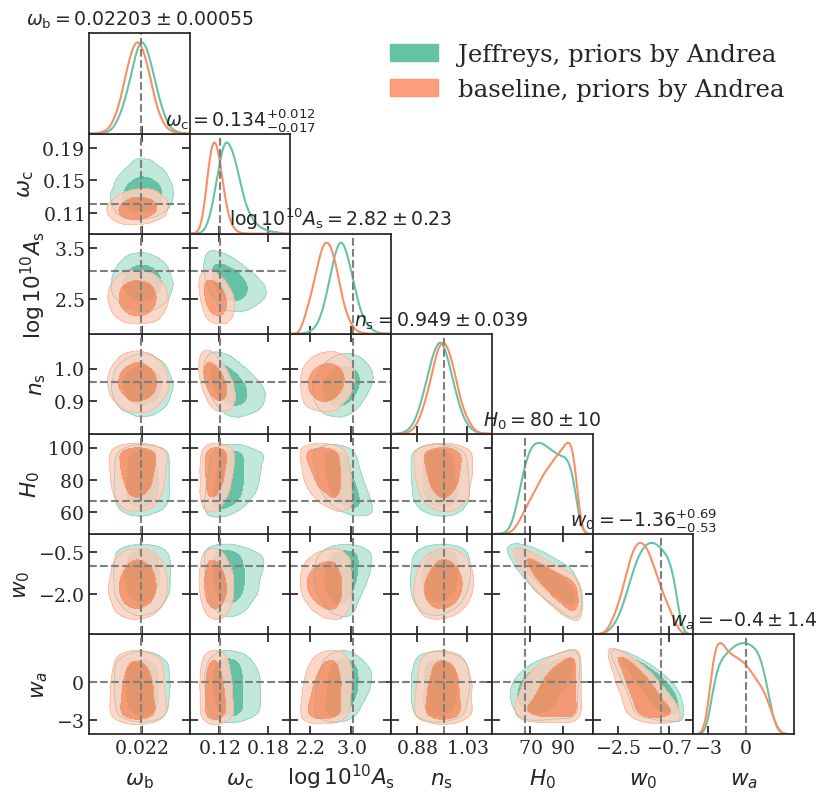

In [8]:
# =============================================================================
# CREATE TRIANGLE PLOT
# =============================================================================
# Create GetDist subplot plotter
g = getdist.plots.getSubplotPlotter(subplot_size=1.3)

# Configure plot appearance settings
plt.rcParams.update({'font.size':16})
g.settings.legend_fontsize=22      # Legend text size
g.settings.axes_fontsize=18        # Axis tick labels size  
g.settings.axes_labelsize=20       # Axis labels size
g.settings.linewidth=4             # Contour line width
g.settings.figure_legend_frame = False  # Remove legend frame
legend_labels=['Jeffreys, priors by Andrea', 'baseline, priors by Andrea']
# Generate the main triangle (corner) plot
g.triangle_plot(
    samples,                          # List of MCSamples objects
    ModelPars,                        # Parameters to include in plot
    legend_labels = legend_labels,    # Labels for legend
    legend_loc = 'upper right',       # Legend position
    title_limit=1,  # first title limit (for 1D plots) is 68% by default
                
    # Filled contour styling for each sample
    contour_args = [
        {'filled':True, 'color': colors[0]}, 
        {'filled':True, 'color': colors[1], 'ls': '-'}, 
        {'filled':True, 'color': colors[2], 'ls': '-'},
        {'filled':True, 'color': colors[3], 'ls': '-'},  
        {'filled':True, 'color': colors[4], 'ls': '-'},  
        {'filled':True, 'color': colors[5], 'ls': '-'}
    ], 
    # 1D marginalized distribution styling
    line_args=[
        {'color': colors[0], 'ls': '-'}, 
        {'color': colors[1], 'ls': '-'}, 
        {'color': colors[2], 'ls': '-'}, 
        {'color': colors[3], 'ls': '-'}, 
        {'color': colors[4], 'ls': '-'}, 
        {'color': colors[5], 'ls': '-'}
    ]
)

if fiducials != None:
    for i in range(len(ModelPars)):
        for j in range(i+1):
            ax = g.subplots[i,j]
            # Add horizontal line for fiducial value of y-parameter (for 2D plots)
            if i != j and ModelPars[i] in fiducials and fiducials[ModelPars[i]] != None:
                ax.axhline(fiducials[ModelPars[i]]['p0'], lw=1.5, color='tab:gray', linestyle='--')
            # Add vertical line for fiducial value of x-parameter
            if ModelPars[j] in fiducials and fiducials[ModelPars[j]] != None:
                ax.axvline(fiducials[ModelPars[j]]['p0'], lw=1.5, color='tab:gray', linestyle='--')


In [30]:
chain_jeff = np.load('../sampling/chains/chain_spec_pbj_DR1_like_jef_andreapedro_priors_lcdm.npz', allow_pickle=True)
chain_baseline = np.load('../sampling/chains/chain_spec_pbj_DR1_like_nojef_andreapedro_priors_lcdm.npz', allow_pickle=True)
chain_tcm = np.load('../sampling/chains/chain_spec_pbj_DR1_like_tcm_andreapedro_priors_lcdm.npz', allow_pickle=True)

In [31]:
# =============================================================================
# GETDIST SAMPLE PREPARATION
# =============================================================================
ModelPars =[ 'ombh2', 'omch2', 'logAs', 'ns', 'H0']
samples = []    
samples.append(
    getdist.MCSamples(
        # Sample data (excluding log-likelihood and weight columns)
        samples = chain_baseline['chain'][:, :len(ModelPars)],
        # Parameter names
        names = [i for i in ModelPars],
        # Sample weights (exponential of log-likelihood)
        weights=np.exp(chain_baseline['weights']),
        # LaTeX labels for parameters (from params_dic)
        labels = [params_dic[p] for p in ModelPars],
        # Smoothing settings for 1D and 2D distributions
        settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35},
        # Parameter ranges for plotting
        #ranges = Ranges
    ) 
)

samples.append(
    getdist.MCSamples(
        # Sample data (excluding log-likelihood and weight columns)
        samples = chain_jeff['chain'][:, :len(ModelPars)],
        # Parameter names
        names = [i for i in ModelPars],
        # Sample weights (exponential of log-likelihood)
        weights=np.exp(chain_jeff['weights']),
        # LaTeX labels for parameters (from params_dic)
        labels = [params_dic[p] for p in ModelPars],
        # Smoothing settings for 1D and 2D distributions
        settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35},
        # Parameter ranges for plotting
        #ranges = Ranges
    ) 
)


samples.append(
    getdist.MCSamples(
        # Sample data (excluding log-likelihood and weight columns)
        samples = chain_tcm['chain'][:, :len(ModelPars)],
        # Parameter names
        names = [i for i in ModelPars],
        # Sample weights (exponential of log-likelihood)
        weights=np.exp(chain_tcm['weights']),
        # LaTeX labels for parameters (from params_dic)
        labels = [params_dic[p] for p in ModelPars],
        # Smoothing settings for 1D and 2D distributions
        settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35},
        # Parameter ranges for plotting
        #ranges = Ranges
    ) 
)

Removed no burn in
Removed no burn in
Removed no burn in


In [32]:
for i in range(len(samples)):
    p = samples[i].getParams() 
    samples[i].addDerived(np.exp(p.logAs)*1e-10, name='As', label=r'A_s')



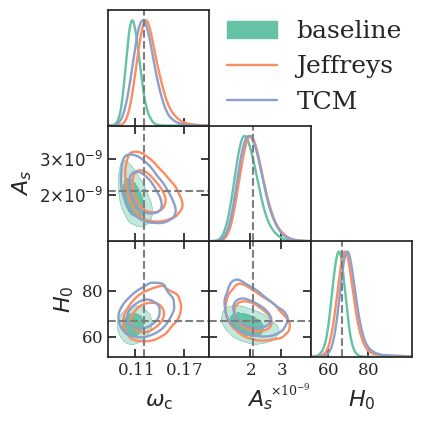

In [38]:
#g = getdist.plots.getSubplotPlotter(subplot_size=1.3)
#ModelPars = ['ombh2', 'omch2', 'As', 'ns', 'H0']
g = getdist.plots.getSubplotPlotter(subplot_size=1.5)
ModelPars = ['omch2', 'As', 'H0']
# Configure plot appearance settings
plt.rcParams.update({'font.size':16})
g.settings.legend_fontsize=22      # Legend text size
g.settings.axes_fontsize=16        # Axis tick labels size  
g.settings.axes_labelsize=20       # Axis labels size
g.settings.linewidth=4             # Contour line width
g.settings.figure_legend_frame = False  # Remove legend frame
legend_labels=['baseline','Jeffreys', 'TCM']
# Generate the main triangle (corner) plot
g.triangle_plot(
    samples,                          # List of MCSamples objects
    ModelPars,                        # Parameters to include in plot
    legend_labels = legend_labels,    # Labels for legend
    legend_loc = 'upper right',       # Legend position
    #title_limit=1,  # first title limit (for 1D plots) is 68% by default
                
    # Filled contour styling for each sample
    contour_args = [
        {'filled':True, 'color': colors[0]}, 
        {'filled':False, 'color': colors[1], 'ls': '-'}, 
        {'filled':False, 'color': colors[2], 'ls': '-'},
        {'filled':True, 'color': colors[3], 'ls': '-'},  
        {'filled':True, 'color': colors[4], 'ls': '-'},  
        {'filled':True, 'color': colors[5], 'ls': '-'}
    ], 
    # 1D marginalized distribution styling
    line_args=[
        {'color': colors[0], 'ls': '-'}, 
        {'color': colors[1], 'ls': '-'}, 
        {'color': colors[2], 'ls': '-'}, 
        {'color': colors[3], 'ls': '-'}, 
        {'color': colors[4], 'ls': '-'}, 
        {'color': colors[5], 'ls': '-'}
    ]
)

if fiducials != None:
    for i in range(len(ModelPars)):
        for j in range(i+1):
            ax = g.subplots[i,j]
            # Add horizontal line for fiducial value of y-parameter (for 2D plots)
            if i != j and ModelPars[i] in fiducials and fiducials[ModelPars[i]] != None:
                ax.axhline(fiducials[ModelPars[i]]['p0'], lw=1.5, color='tab:gray', linestyle='--')
            # Add vertical line for fiducial value of x-parameter
            if ModelPars[j] in fiducials and fiducials[ModelPars[j]] != None:
                ax.axvline(fiducials[ModelPars[j]]['p0'], lw=1.5, color='tab:gray', linestyle='--')

In [39]:
chain_jeff = np.load('../sampling/chains/chain_spec_pbj_DR1_like_jef_andreapedro_priors_cpl.npz', allow_pickle=True)
chain_baseline = np.load('../sampling/chains/chain_spec_pbj_DR1_like_nojef_andreapedro_priors_cpl.npz', allow_pickle=True)
chain_tcm = np.load('../sampling/chains/chain_spec_pbj_DR1_like_tcm_andreapedro_priors_cpl_onlyAap.npz', allow_pickle=True)

In [40]:
# =============================================================================
# GETDIST SAMPLE PREPARATION
# =============================================================================
ModelPars =[ 'ombh2', 'omch2', 'As', 'ns', 'H0', 'w0', 'wa']
samples = []    
samples.append(
    getdist.MCSamples(
        # Sample data (excluding log-likelihood and weight columns)
        samples = chain_baseline['chain'][:, :len(ModelPars)],
        # Parameter names
        names = [i for i in ModelPars],
        # Sample weights (exponential of log-likelihood)
        weights=np.exp(chain_baseline['weights']),
        # LaTeX labels for parameters (from params_dic)
        labels = [params_dic[p] for p in ModelPars],
        # Smoothing settings for 1D and 2D distributions
        settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35},
        # Parameter ranges for plotting
        #ranges = Ranges
    ) 
)

samples.append(
    getdist.MCSamples(
        # Sample data (excluding log-likelihood and weight columns)
        samples = chain_jeff['chain'][:, :len(ModelPars)],
        # Parameter names
        names = [i for i in ModelPars],
        # Sample weights (exponential of log-likelihood)
        weights=np.exp(chain_jeff['weights']),
        # LaTeX labels for parameters (from params_dic)
        labels = [params_dic[p] for p in ModelPars],
        # Smoothing settings for 1D and 2D distributions
        settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35},
        # Parameter ranges for plotting
        #ranges = Ranges
    ) 
)


samples.append(
    getdist.MCSamples(
        # Sample data (excluding log-likelihood and weight columns)
        samples = chain_tcm['chain'][:, :len(ModelPars)],
        # Parameter names
        names = [i for i in ModelPars],
        # Sample weights (exponential of log-likelihood)
        weights=np.exp(chain_tcm['weights']),
        # LaTeX labels for parameters (from params_dic)
        labels = [params_dic[p] for p in ModelPars],
        # Smoothing settings for 1D and 2D distributions
        settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35},
        # Parameter ranges for plotting
        #ranges = Ranges
    ) 
)

Removed no burn in
Removed no burn in
Removed no burn in


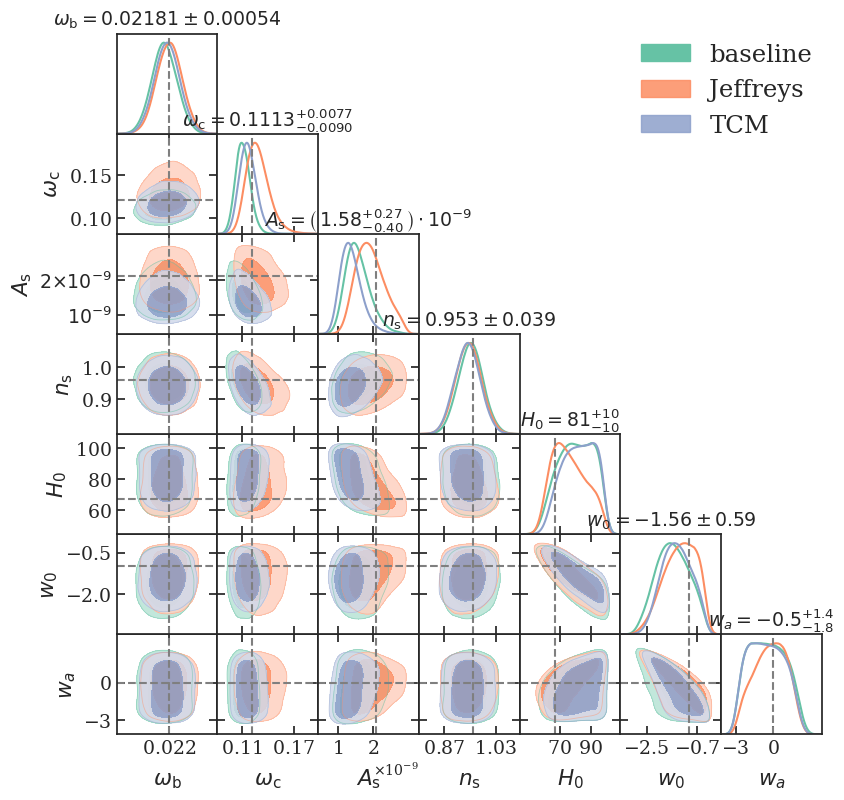

In [41]:
g = getdist.plots.getSubplotPlotter(subplot_size=1.3)

# Configure plot appearance settings
plt.rcParams.update({'font.size':16})
g.settings.legend_fontsize=22      # Legend text size
g.settings.axes_fontsize=18        # Axis tick labels size  
g.settings.axes_labelsize=20       # Axis labels size
g.settings.linewidth=4             # Contour line width
g.settings.figure_legend_frame = False  # Remove legend frame
legend_labels=['baseline','Jeffreys', 'TCM']
# Generate the main triangle (corner) plot
g.triangle_plot(
    samples,                          # List of MCSamples objects
    ModelPars,                        # Parameters to include in plot
    legend_labels = legend_labels,    # Labels for legend
    legend_loc = 'upper right',       # Legend position
    title_limit=1,  # first title limit (for 1D plots) is 68% by default
                
    # Filled contour styling for each sample
    contour_args = [
        {'filled':True, 'color': colors[0]}, 
        {'filled':True, 'color': colors[1], 'ls': '-'}, 
        {'filled':True, 'color': colors[2], 'ls': '-'},
        {'filled':True, 'color': colors[3], 'ls': '-'},  
        {'filled':True, 'color': colors[4], 'ls': '-'},  
        {'filled':True, 'color': colors[5], 'ls': '-'}
    ], 
    # 1D marginalized distribution styling
    line_args=[
        {'color': colors[0], 'ls': '-'}, 
        {'color': colors[1], 'ls': '-'}, 
        {'color': colors[2], 'ls': '-'}, 
        {'color': colors[3], 'ls': '-'}, 
        {'color': colors[4], 'ls': '-'}, 
        {'color': colors[5], 'ls': '-'}
    ]
)

if fiducials != None:
    for i in range(len(ModelPars)):
        for j in range(i+1):
            ax = g.subplots[i,j]
            # Add horizontal line for fiducial value of y-parameter (for 2D plots)
            if i != j and ModelPars[i] in fiducials and fiducials[ModelPars[i]] != None:
                ax.axhline(fiducials[ModelPars[i]]['p0'], lw=1.5, color='tab:gray', linestyle='--')
            # Add vertical line for fiducial value of x-parameter
            if ModelPars[j] in fiducials and fiducials[ModelPars[j]] != None:
                ax.axvline(fiducials[ModelPars[j]]['p0'], lw=1.5, color='tab:gray', linestyle='--')

In [ ]:
g = getdist.plots.getSubplotPlotter(subplot_size=1.5)
ModelPars =['H0', 'w0', 'wa']
# Configure plot appearance settings
plt.rcParams.update({'font.size':16})
g.settings.legend_fontsize=22      # Legend text size
g.settings.axes_fontsize=16        # Axis tick labels size  
g.settings.axes_labelsize=20       # Axis labels size
g.settings.linewidth=4             # Contour line width
g.settings.figure_legend_frame = False  # Remove legend frame
legend_labels=['baseline','Jeffreys', 'TCM']
# Generate the main triangle (corner) plot
g.triangle_plot(
    samples,                          # List of MCSamples objects
    ModelPars,                        # Parameters to include in plot
    legend_labels = legend_labels,    # Labels for legend
    legend_loc = 'upper right',       # Legend position
    title_limit=1,  # first title limit (for 1D plots) is 68% by default
                
    # Filled contour styling for each sample
    contour_args = [
        {'filled':True, 'color': colors[0]}, 
        {'filled':False, 'color': colors[1], 'ls': '-'}, 
        {'filled':False, 'color': colors[2], 'ls': '-'},
        {'filled':True, 'color': colors[3], 'ls': '-'},  
        {'filled':True, 'color': colors[4], 'ls': '-'},  
        {'filled':True, 'color': colors[5], 'ls': '-'}
    ], 
    # 1D marginalized distribution styling
    line_args=[
        {'color': colors[0], 'ls': '-'}, 
        {'color': colors[1], 'ls': '-'}, 
        {'color': colors[2], 'ls': '-'}, 
        {'color': colors[3], 'ls': '-'}, 
        {'color': colors[4], 'ls': '-'}, 
        {'color': colors[5], 'ls': '-'}
    ]
)

if fiducials != None:
    for i in range(len(ModelPars)):
        for j in range(i+1):
            ax = g.subplots[i,j]
            # Add horizontal line for fiducial value of y-parameter (for 2D plots)
            if i != j and ModelPars[i] in fiducials and fiducials[ModelPars[i]] != None:
                ax.axhline(fiducials[ModelPars[i]]['p0'], lw=1.5, color='tab:gray', linestyle='--')
            # Add vertical line for fiducial value of x-parameter
            if ModelPars[j] in fiducials and fiducials[ModelPars[j]] != None:
                ax.axvline(fiducials[ModelPars[j]]['p0'], lw=1.5, color='tab:gray', linestyle='--')